In [1]:
import subprocess
import sys

print("Installing dependencies...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "torch", "scikit-learn", "matplotlib", "seaborn", "pandas", "numpy"])
print("✓ Dependencies installed")

Installing dependencies...
✓ Dependencies installed


In [2]:
from google.colab import drive
import os
from pathlib import Path

# Ensure the mount point is clear before mounting
if os.path.exists('/content/drive'):
    try:
        # Unmount if previously mounted
        drive.flush_and_unmount()
    except ValueError:
        pass # Drive was not mounted, continue
    # Remove any remaining files/directories if unmount failed or was not possible
    # A more robust approach might iterate and remove specific items, but this is a common fix
    for item in os.listdir('/content/drive'):
        item_path = os.path.join('/content/drive', item)
        if os.path.isdir(item_path):
            import shutil
            shutil.rmtree(item_path)
        else:
            os.remove(item_path)

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)
print("✓ Google Drive mounted")

# Create working directory
WORK_DIR = Path('/content/drive/MyDrive/ckd_model')
WORK_DIR.mkdir(exist_ok=True, parents=True)
DATA_DIR = WORK_DIR / 'data'
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = WORK_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Working directory: {WORK_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
✓ Google Drive mounted
Working directory: /content/drive/MyDrive/ckd_model
Data directory: /content/drive/MyDrive/ckd_model/data
Output directory: /content/drive/MyDrive/ckd_model/outputs


In [3]:
from google.colab import files

print("Upload your ckd.csv file:")
uploaded = files.upload()

# Move uploaded file
if uploaded:
    csv_file = list(uploaded.keys())[0]
    import shutil
    shutil.move(f'/content/{csv_file}', f'{DATA_DIR}/ckd.csv')
    print(f"✓ File saved to {DATA_DIR}/ckd.csv")
else:
    print("No file uploaded. Using file from Google Drive...")
    # Update this path if your file is elsewhere in Google Drive
    csv_path = '/content/drive/MyDrive/ckd.csv'
    if os.path.exists(csv_path):
        import shutil
        shutil.copy(csv_path, f'{DATA_DIR}/ckd.csv')
        print(f"✓ File copied from {csv_path}")


Upload your ckd.csv file:


Saving ckd.csv to ckd.csv
✓ File saved to /content/drive/MyDrive/ckd_model/data/ckd.csv


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score,
    precision_recall_curve, average_precision_score,
    log_loss, brier_score_loss
)
from sklearn.calibration import calibration_curve
from datetime import datetime
import json
import warnings

warnings.filterwarnings('ignore')

# Check GPU
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    device = 'cuda'
else:
    print("Using CPU (slower, consider enabling GPU in Runtime settings)")
    device = 'cpu'


GPU available: False
Using CPU (slower, consider enabling GPU in Runtime settings)


In [5]:
import pandas as pd
import numpy as np

class CKDDataPreprocessor:
    """Data preprocessing pipeline for CKD data."""

    def __init__(self, verbose=True):
        self.verbose = verbose
        self.dynamic_features = [
            'creatinine', 'egfr', 'potassium', 'hemoglobin', 'glucose',
            'albumin', 'sodium', 'bicarbonate', 'calcium', 'phosphate', 'wbc', 'rbc'
        ]
        self.static_features = ['age', 'gender', 'diabetes_flag', 'hypertension_flag', 'cad_flag']
        self.feature_stats = {}

    def preprocess(self, filepath, handle_missing='forward_fill'):
        """Complete preprocessing pipeline."""
        print("\n" + "="*80)
        print("PREPROCESSING DATA")
        print("="*80)

        # Load
        df = pd.read_csv(filepath)
        print(f"✓ Loaded {len(df):,} records for {df['subject_id'].nunique():,} patients")

        # Convert date
        df['record_date'] = pd.to_datetime(df['record_date'], format='%d-%m-%Y')

        # Sort
        df = df.sort_values(['subject_id', 'record_date']).reset_index(drop=True)
        print("✓ Data sorted")

        # Convert gender
        df['gender'] = df['gender'].map({'F': 0, 'M': 1})
        print("✓ Gender encoded")

        # Calculate time gaps
        df['delta_t'] = 0.0
        for subject_id in df['subject_id'].unique():
            mask = df['subject_id'] == subject_id
            indices = df[mask].index
            dates = df.loc[indices, 'record_date'].values
            for i in range(1, len(indices)):
                time_diff = (pd.Timestamp(dates[i]) - pd.Timestamp(dates[i-1])).days
                df.loc[indices[i], 'delta_t'] = time_diff
        print(f"✓ Time gaps calculated (mean: {df['delta_t'].mean():.1f} days)")

        # Missingness masks
        for feature in self.dynamic_features:
            df[f'{feature}_mask'] = (~df[feature].isna()).astype(int)
        print(f"✓ Missingness masks created")

        # Target derivation
        df['next_ckd_stage'] = df.groupby('subject_id')['ckd_stage'].shift(-1)

        def get_trend(row):
            if pd.isna(row['next_ckd_stage']):
                return np.nan
            if row['next_ckd_stage'] < row['ckd_stage']:
                return 'Improved'
            elif row['next_ckd_stage'] == row['ckd_stage']:
                return 'Stable'
            else:
                return 'Worsened'

        df['clinical_trend'] = df.apply(get_trend, axis=1)
        print("✓ Targets derived")

        # Remove last visits
        initial = len(df)
        df = df.dropna(subset=['next_ckd_stage', 'clinical_trend']).reset_index(drop=True)
        print(f"✓ Removed {initial - len(df):,} last visits")

        # Ensure dynamic features are numeric before imputation
        for feature in self.dynamic_features:
            df[feature] = pd.to_numeric(df[feature], errors='coerce')

        # Handle missing values
        for feature in self.dynamic_features:
            df[feature] = df.groupby('subject_id')[feature].transform(lambda x: x.ffill()) # Apply ffill within groups
            # If still NaN after ffill (e.g., first value in group is NaN), fill with overall mean
            df[feature].fillna(df[feature].mean(), inplace=True)
        print("✓ Missing values imputed")

        # Compute statistics
        for feature in self.dynamic_features:
            self.feature_stats[feature] = {
                'mean': float(df[feature].mean()),
                'std': float(df[feature].std()),
                'min': float(df[feature].min()),
                'max': float(df[feature].max())
            }
        print(f"✓ Feature statistics computed")

        print("="*80)
        return df, self.feature_stats

In [6]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

class CKDTimeSeriesDataset(Dataset):
    """Custom PyTorch Dataset for time series data."""

    def __init__(self, df, dynamic_features, static_features, max_seq_len=50):
        self.df = df.copy()
        self.dynamic_features = dynamic_features
        self.static_features = static_features
        self.max_seq_len = max_seq_len

        self.trend_map = {'Improved': 0, 'Stable': 1, 'Worsened': 2}

        # Group by subject
        self.subject_ids = df['subject_id'].unique()
        self.subject_data = {sid: df[df['subject_id'] == sid].reset_index(drop=True)
                             for sid in self.subject_ids}

        # Scaling
        self.dynamic_scaler = StandardScaler()
        self.dynamic_scaler.fit(df[dynamic_features].values)

        self.static_scaler = StandardScaler()
        self.static_scaler.fit(df[static_features].values)

        # Empirical means
        self.empirical_mean = {f: df[f].mean() for f in dynamic_features}

        print(f"✓ Dataset initialized: {len(self.subject_ids)} patients")

    def __len__(self):
        return len(self.subject_ids)

    def __getitem__(self, idx):
        subject_id = self.subject_ids[idx]
        patient_data = self.subject_data[subject_id]

        seq_len = min(len(patient_data), self.max_seq_len)

        # Extract features
        dynamic_x = patient_data[self.dynamic_features].iloc[:seq_len].values
        delta_t = patient_data['delta_t'].iloc[:seq_len].values

        # Extract masks
        mask_cols = [f'{f}_mask' for f in self.dynamic_features]
        mask = patient_data[mask_cols].iloc[:seq_len].values

        # Extract static
        static_x = patient_data[self.static_features].iloc[0].values

        # Targets
        target_stage = int(patient_data['next_ckd_stage'].iloc[0])
        target_trend = self.trend_map[patient_data['clinical_trend'].iloc[0]]

        # Scale
        dynamic_x = self.dynamic_scaler.transform(dynamic_x)
        static_x = self.static_scaler.transform(static_x.reshape(1, -1)).flatten()

        # Pad
        if seq_len < self.max_seq_len:
            pad_len = self.max_seq_len - seq_len
            dynamic_x = np.vstack([dynamic_x, np.zeros((pad_len, len(self.dynamic_features)))])
            delta_t = np.concatenate([delta_t, np.zeros(pad_len)])
            mask = np.vstack([mask, np.zeros((pad_len, len(self.dynamic_features)))])

        return {
            'dynamic_x': torch.FloatTensor(dynamic_x),
            'delta_t': torch.FloatTensor(delta_t),
            'mask': torch.FloatTensor(mask),
            'static_x': torch.FloatTensor(static_x),
            'seq_length': torch.LongTensor([seq_len]),
            'target_stage': torch.LongTensor([target_stage]),
            'target_trend': torch.LongTensor([target_trend])
        }

In [7]:
import torch.nn as nn
class GRUDCell(nn.Module):
    """GRU-D Cell with temporal decay."""

    def __init__(self, input_size, hidden_size, empirical_mean=None):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        if empirical_mean is not None:
            mean_values = [empirical_mean.get(f, 0.0) for f in sorted(empirical_mean.keys())]
            self.register_buffer('empirical_mean', torch.tensor(mean_values, dtype=torch.float32))
        else:
            self.register_buffer('empirical_mean', torch.zeros(input_size))

        # GRU parameters
        self.W_xz = nn.Linear(input_size, hidden_size)
        self.W_hz = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_xr = nn.Linear(input_size, hidden_size)
        self.W_hr = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=False)

        # Decay
        self.W_decay = nn.Linear(1, hidden_size, bias=True)

    def forward(self, x_t, delta_t, m_t, h_prev):
        """Forward pass."""
        delta_t = delta_t.unsqueeze(1)
        decay = torch.sigmoid(self.W_decay(delta_t))
        h_decay = decay * h_prev

        # Impute missing
        empirical_mean = self.empirical_mean.unsqueeze(0).expand(x_t.size(0), -1)
        x_impute = m_t * x_t + (1 - m_t) * empirical_mean

        # GRU update
        z_t = torch.sigmoid(self.W_xz(x_impute) + self.W_hz(h_decay))
        r_t = torch.sigmoid(self.W_xr(x_impute) + self.W_hr(h_decay))
        h_tilde = torch.tanh(self.W_xh(x_impute) + self.W_hh(r_t * h_decay))
        h_t = (1 - z_t) * h_tilde + z_t * h_decay

        return h_t


class AttentionMechanism(nn.Module):
    """Multi-head attention."""

    def __init__(self, hidden_dim, num_heads=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True, dropout=0.1)
        self.ln = nn.LayerNorm(hidden_dim)

    def forward(self, hidden_states, seq_lengths):
        """Forward pass."""
        batch_size, seq_len, _ = hidden_states.size()

        mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=hidden_states.device)
        for i, length in enumerate(seq_lengths):
            length = length.item()
            if length < seq_len:
                mask[i, length:] = True

        attn_output, _ = self.attention(hidden_states, hidden_states, hidden_states,
                                        key_padding_mask=mask)
        attn_output = self.ln(attn_output + hidden_states)
        context = attn_output.mean(dim=1)

        return context, None


class HybridGRUDModel(nn.Module):
    """Complete GRU-D + Attention model."""

    def __init__(self, num_dynamic_features=12, num_static_features=5,
                 hidden_dim=64, empirical_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim

        # GRU-D
        self.gru_d = GRUDCell(num_dynamic_features, hidden_dim, empirical_mean)

        # Attention
        self.attention = AttentionMechanism(hidden_dim, num_heads=4)

        # Static fusion
        self.static_network = nn.Sequential(
            nn.Linear(num_static_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.fusion_gate = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        # Task heads
        self.stage_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 6)
        )

        self.trend_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 3)
        )

    def forward(self, dynamic_x, delta_t, mask, static_x, seq_length):
        """Forward pass."""
        batch_size = dynamic_x.size(0)
        device = dynamic_x.device

        # GRU-D
        hidden_states = []
        h = torch.zeros(batch_size, self.hidden_dim, device=device)

        for t in range(dynamic_x.size(1)):
            h = self.gru_d(dynamic_x[:, t, :], delta_t[:, t], mask[:, t, :], h)
            hidden_states.append(h)

        hidden_states = torch.stack(hidden_states, dim=1)

        # Attention
        context, _ = self.attention(hidden_states, seq_length)

        # Static fusion
        static_processed = self.static_network(static_x)
        combined_for_gate = torch.cat([context, static_processed], dim=1)
        gate = self.fusion_gate(combined_for_gate)
        combined = gate * context + (1 - gate) * static_processed

        # Task heads
        logits_stage = self.stage_head(combined)
        logits_trend = self.trend_head(combined)

        return logits_stage, logits_trend

In [8]:
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score,
    average_precision_score,
    log_loss
)
from sklearn.preprocessing import label_binarize
import torch

class Trainer:
    """Training loop with comprehensive metrics."""

    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_f1': [], 'val_f1': [],
            'train_acc': [], 'val_acc': []
        }
        self.best_f1 = -np.inf

    # ── helpers ───────────────────────────────────────────────────────────────
    @staticmethod
    def _softmax(logits):
        """Stable row-wise softmax."""
        e = np.exp(logits - logits.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    @staticmethod
    def _ece(y_true, probs, n_bins=10):
        """Expected Calibration Error."""
        confidences = probs.max(axis=1)
        predictions = probs.argmax(axis=1)
        correct      = (predictions == y_true).astype(float)
        bin_edges = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
            mask = (confidences >= lo) & (confidences < hi)
            if mask.sum() == 0:
                continue
            acc_bin  = correct[mask].mean()
            conf_bin = confidences[mask].mean()
            ece += mask.mean() * abs(acc_bin - conf_bin)
        return float(ece)

    @staticmethod
    def _brier_multiclass(y_true, probs):
        """Brier score for multiclass (mean over classes)."""
        n_classes = probs.shape[1]
        ohe = np.zeros_like(probs)
        ohe[np.arange(len(y_true)), y_true] = 1
        return float(np.mean((probs - ohe) ** 2))

    # ── training loop ─────────────────────────────────────────────────────────
    def fit(self, train_loader, val_loader, test_loader, epochs=50,
            learning_rate=1e-3, patience=10, weight_decay=1e-5):

        loss_fn_stage = nn.CrossEntropyLoss()
        loss_fn_trend = nn.CrossEntropyLoss()

        optimizer = optim.AdamW(self.model.parameters(),
                                lr=learning_rate, weight_decay=weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=5)

        print("\n" + "="*80)
        print("TRAINING")
        print("="*80)

        patience_counter = 0

        for epoch in range(1, epochs + 1):
            # ── train ──────────────────────────────────────────────────────
            self.model.train()
            train_loss = 0.0
            tr_preds, tr_targets = [], []

            for batch in train_loader:
                batch = {k: v.to(self.device) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}

                logits_stage, logits_trend = self.model(
                    batch['dynamic_x'], batch['delta_t'], batch['mask'],
                    batch['static_x'], batch['seq_length'])

                loss = (loss_fn_stage(logits_stage, batch['target_stage'].squeeze()) +
                        loss_fn_trend(logits_trend, batch['target_trend'].squeeze()))

                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

                train_loss += loss.item()
                tr_preds.extend(logits_stage.argmax(1).cpu().numpy())
                tr_targets.extend(batch['target_stage'].squeeze().cpu().numpy())

            train_f1  = f1_score(tr_targets, tr_preds, average='macro', zero_division=0)
            train_acc = accuracy_score(tr_targets, tr_preds)
            train_loss /= len(train_loader)

            # ── validate ───────────────────────────────────────────────────
            self.model.eval()
            val_loss = 0.0
            v_preds, v_targets = [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch = {k: v.to(self.device) if isinstance(v, torch.Tensor) else v
                             for k, v in batch.items()}
                    logits_stage, logits_trend = self.model(
                        batch['dynamic_x'], batch['delta_t'], batch['mask'],
                        batch['static_x'], batch['seq_length'])
                    loss = (loss_fn_stage(logits_stage, batch['target_stage'].squeeze()) +
                            loss_fn_trend(logits_trend, batch['target_trend'].squeeze()))
                    val_loss += loss.item()
                    v_preds.extend(logits_stage.argmax(1).cpu().numpy())
                    v_targets.extend(batch['target_stage'].squeeze().cpu().numpy())

            val_f1  = f1_score(v_targets, v_preds, average='macro', zero_division=0)
            val_acc = accuracy_score(v_targets, v_preds)
            val_loss /= len(val_loader)

            for k, v in zip(
                ['train_loss','val_loss','train_f1','val_f1','train_acc','val_acc'],
                [train_loss, val_loss, train_f1, val_f1, train_acc, val_acc]):
                self.history[k].append(v)

            scheduler.step(val_f1)

            if epoch % 5 == 0:
                print(f"Epoch {epoch:3d} | "
                      f"TrainLoss: {train_loss:.4f}  ValLoss: {val_loss:.4f} | "
                      f"TrainAcc: {train_acc:.4f}  ValAcc: {val_acc:.4f} | "
                      f"TrainF1: {train_f1:.4f}  ValF1: {val_f1:.4f}")

            if val_f1 > self.best_f1:
                self.best_f1 = val_f1; patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}"); break

        print("="*80)

        # ── test evaluation ────────────────────────────────────────────────
        self.model.eval()
        t_preds, t_targets, t_logits_all = [], [], []

        with torch.no_grad():
            for batch in test_loader:
                batch = {k: v.to(self.device) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}
                logits_stage, _ = self.model(
                    batch['dynamic_x'], batch['delta_t'], batch['mask'],
                    batch['static_x'], batch['seq_length'])
                t_logits_all.append(logits_stage.cpu().numpy())
                t_preds.extend(logits_stage.argmax(1).cpu().numpy())
                t_targets.extend(batch['target_stage'].squeeze().cpu().numpy())

        t_targets = np.array(t_targets)
        t_preds   = np.array(t_preds)
        all_logits = np.concatenate(t_logits_all, axis=0)
        probs      = self._softmax(all_logits)

        n_classes = probs.shape[1]
        present   = np.unique(t_targets)

        # ── core metrics ──────────────────────────────────────────────────
        test_acc     = accuracy_score(t_targets, t_preds)
        test_macro_f1 = f1_score(t_targets, t_preds, average='macro',  zero_division=0)
        test_weighted_f1 = f1_score(t_targets, t_preds, average='weighted', zero_division=0)
        test_precision = precision_score(t_targets, t_preds, average='macro', zero_division=0)
        test_recall   = recall_score(t_targets, t_preds, average='macro', zero_division=0)

        # loss (cross-entropy)
        test_loss = log_loss(t_targets, probs, labels=list(range(n_classes)))

        # AUC-ROC (OvR, macro)
        try:
            if len(present) > 1:
                t_bin = label_binarize(t_targets, classes=list(range(n_classes)))
                auc_roc = roc_auc_score(t_bin[:, present], probs[:, present],
                                        multi_class='ovr', average='macro')
            else:
                auc_roc = float('nan')
        except Exception:
            auc_roc = float('nan')

        # PR-AUC (macro average of per-class AP)
        t_bin_all = label_binarize(t_targets, classes=list(range(n_classes)))
        pr_auc_scores = []
        for c in present:
            if t_bin_all[:, c].sum() > 0:
                pr_auc_scores.append(average_precision_score(t_bin_all[:, c], probs[:, c]))
        pr_auc = float(np.mean(pr_auc_scores)) if pr_auc_scores else float('nan')

        # ECE
        ece = self._ece(t_targets, probs)

        # Brier score
        brier = self._brier_multiclass(t_targets, probs)

        # Per-class precision, recall, F1
        per_class = classification_report(t_targets, t_preds, output_dict=True, zero_division=0)

        # Confusion matrix
        cm = confusion_matrix(t_targets, t_preds, labels=list(range(n_classes)))

        # Store everything
        self.history.update({
            'test_acc':         test_acc,
            'test_loss':        test_loss,
            'test_macro_f1':    test_macro_f1,
            'test_weighted_f1': test_weighted_f1,
            'test_precision':   test_precision,
            'test_recall':      test_recall,
            'test_auc_roc':     auc_roc,
            'test_pr_auc':      pr_auc,
            'test_ece':         ece,
            'test_brier':       brier,
            'test_per_class':   per_class,
            'test_cm':          cm.tolist(),
            'test_probs':       probs.tolist(),
            'test_targets':     t_targets.tolist(),
            'test_preds':       t_preds.tolist(),
        })

        print(f"\n{'='*80}")
        print("TEST RESULTS")
        print(f"{'='*80}")
        print(f"  Accuracy           : {test_acc:.4f}")
        print(f"  Loss (Cross-Entropy): {test_loss:.4f}")
        print(f"  Macro F1           : {test_macro_f1:.4f}")
        print(f"  Weighted F1        : {test_weighted_f1:.4f}")
        print(f"  Macro Precision    : {test_precision:.4f}")
        print(f"  Macro Recall       : {test_recall:.4f}")
        print(f"  AUC-ROC (macro)    : {auc_roc:.4f}" if not np.isnan(auc_roc) else "  AUC-ROC           : N/A (single class in test set)")
        print(f"  PR-AUC (macro)     : {pr_auc:.4f}" if not np.isnan(pr_auc) else "  PR-AUC            : N/A")
        print(f"  ECE                : {ece:.4f}")
        print(f"  Brier Score        : {brier:.4f}")
        print(f"{'='*80}")
        print("\nPer-class Report:")
        print(classification_report(t_targets, t_preds, zero_division=0))

        return self.history


In [9]:
import json
preprocessor = CKDDataPreprocessor(verbose=True)
df, feature_stats = preprocessor.preprocess(f'{DATA_DIR}/ckd.csv')

dynamic_features = [
    'creatinine', 'egfr', 'potassium', 'hemoglobin', 'glucose',
    'albumin', 'sodium', 'bicarbonate', 'calcium', 'phosphate', 'wbc', 'rbc'
]
static_features = ['age', 'gender', 'diabetes_flag', 'hypertension_flag', 'cad_flag']

# Save stats
with open(f'{OUTPUT_DIR}/feature_stats.json', 'w') as f:
    json.dump(feature_stats, f, indent=2)
print(f"✓ Feature stats saved")


PREPROCESSING DATA
✓ Loaded 413,775 records for 11,500 patients
✓ Data sorted
✓ Gender encoded
✓ Time gaps calculated (mean: 37.7 days)
✓ Missingness masks created
✓ Targets derived
✓ Removed 11,500 last visits
✓ Missing values imputed
✓ Feature statistics computed
✓ Feature stats saved


In [10]:
# Full dataset
dataset = CKDTimeSeriesDataset(df, dynamic_features, static_features, max_seq_len=50)

# Split (grouped by patient)
subject_ids = df['subject_id'].unique()
np.random.seed(42)
np.random.shuffle(subject_ids)

n = len(subject_ids)
train_size = int(n * 0.6)
val_size = int(n * 0.2)

train_ids = subject_ids[:train_size]
val_ids = subject_ids[train_size:train_size + val_size]
test_ids = subject_ids[train_size + val_size:]

print(f"\nData Split:")
print(f"  Train: {len(train_ids)} patients ({len(train_ids)/n*100:.1f}%)")
print(f"  Val:   {len(val_ids)} patients ({len(val_ids)/n*100:.1f}%)")
print(f"  Test:  {len(test_ids)} patients ({len(test_ids)/n*100:.1f}%)")

# Create subset datasets
train_mask = df['subject_id'].isin(train_ids)
val_mask = df['subject_id'].isin(val_ids)
test_mask = df['subject_id'].isin(test_ids)

train_dataset = CKDTimeSeriesDataset(df[train_mask], dynamic_features, static_features)
val_dataset = CKDTimeSeriesDataset(df[val_mask], dynamic_features, static_features)
test_dataset = CKDTimeSeriesDataset(df[test_mask], dynamic_features, static_features)

# Create dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

✓ Dataset initialized: 10970 patients

Data Split:
  Train: 6582 patients (60.0%)
  Val:   2194 patients (20.0%)
  Test:  2194 patients (20.0%)
✓ Dataset initialized: 6582 patients
✓ Dataset initialized: 2194 patients
✓ Dataset initialized: 2194 patients

DataLoaders created:
  Train batches: 206
  Val batches: 69
  Test batches: 69


In [11]:
import torch
import json
from pathlib import Path

# Define OUTPUT_DIR locally for this cell to ensure it's always available
OUTPUT_DIR = Path('/content/drive/MyDrive/ckd_model/outputs')

# Check if feature_stats is defined, otherwise load it from file
if 'feature_stats' not in locals() and 'feature_stats' not in globals():
    feature_stats_path = OUTPUT_DIR / 'feature_stats.json'
    if feature_stats_path.exists():
        with open(feature_stats_path, 'r') as f:
            feature_stats = json.load(f)
        print("✓ Loaded feature_stats from file.")
    else:
        raise NameError("feature_stats is not defined and 'feature_stats.json' not found. Please ensure cell 0eM6xtLVipyo is run before this cell.")

empirical_mean = {f: feature_stats[f]['mean'] for f in feature_stats}

# Define device for model training
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'
print(f"Using device: {device}")

# Model
model = HybridGRUDModel(
    num_dynamic_features=len(dynamic_features),
    num_static_features=len(static_features),
    hidden_dim=64,
    empirical_mean=empirical_mean
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel created:")
print(f"  Total params: {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")

# Train
trainer = Trainer(model, device=device)
history = trainer.fit(
    train_loader, val_loader, test_loader,
    epochs=50,
    learning_rate=1e-3,
    patience=10,
    weight_decay=1e-5
)


Using device: cpu

Model created:
  Total params: 48,937
  Trainable params: 48,937

TRAINING
Epoch   5 | TrainLoss: 0.6470  ValLoss: 0.6213 | TrainAcc: 0.8991  ValAcc: 0.9088 | TrainF1: 0.8885  ValF1: 0.9027
Epoch  10 | TrainLoss: 0.5298  ValLoss: 0.5131 | TrainAcc: 0.9284  ValAcc: 0.9298 | TrainF1: 0.9218  ValF1: 0.9246
Epoch  15 | TrainLoss: 0.4487  ValLoss: 0.5203 | TrainAcc: 0.9386  ValAcc: 0.9266 | TrainF1: 0.9325  ValF1: 0.9215
Epoch  20 | TrainLoss: 0.3386  ValLoss: 0.4897 | TrainAcc: 0.9584  ValAcc: 0.9298 | TrainF1: 0.9539  ValF1: 0.9243
Epoch  25 | TrainLoss: 0.2774  ValLoss: 0.4361 | TrainAcc: 0.9669  ValAcc: 0.9394 | TrainF1: 0.9638  ValF1: 0.9359
Epoch  30 | TrainLoss: 0.2520  ValLoss: 0.5278 | TrainAcc: 0.9669  ValAcc: 0.9257 | TrainF1: 0.9639  ValF1: 0.9204
Epoch  35 | TrainLoss: 0.1896  ValLoss: 0.4850 | TrainAcc: 0.9786  ValAcc: 0.9394 | TrainF1: 0.9773  ValF1: 0.9355
Early stopping at epoch 37

TEST RESULTS
  Accuracy           : 0.9403
  Loss (Cross-Entropy): 0.2377

In [12]:
import os
from pathlib import Path

OUTPUT_DIR = Path('/content/drive/MyDrive/ckd_model/outputs')

print(f"Contents of {OUTPUT_DIR}:")
if OUTPUT_DIR.exists():
    for item in os.listdir(OUTPUT_DIR):
        print(f"- {item}")
else:
    print(f"Directory does not exist: {OUTPUT_DIR}")


Contents of /content/drive/MyDrive/ckd_model/outputs:
- training_curves.png
- confusion_matrix.png
- roc_curves.png
- per_class_metrics.png
- calibration.png
- pr_curves.png
- confidence_distribution.png
- model.pt
- history.json
- feature_stats.json


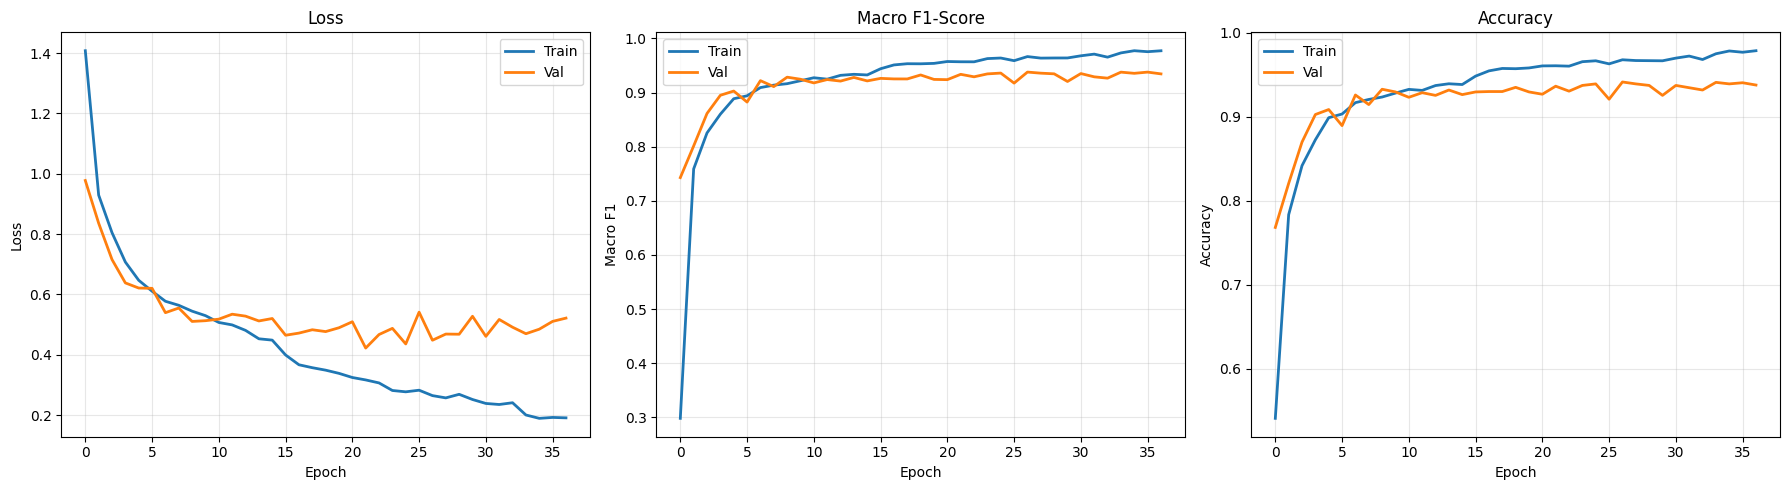

✓ Training curves saved


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

# Define OUTPUT_DIR locally for this cell to ensure it's always available
OUTPUT_DIR = Path('/content/drive/MyDrive/ckd_model/outputs')

# Ensure the output directory exists
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# ── 1. Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   lw=2)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(history['train_f1'], label='Train', lw=2)
axes[1].plot(history['val_f1'],   label='Val',   lw=2)
axes[1].set(xlabel='Epoch', ylabel='Macro F1', title='Macro F1-Score')
axes[1].legend(); axes[1].grid(True, alpha=.3)

axes[2].plot(history['train_acc'], label='Train', lw=2)
axes[2].plot(history['val_acc'],   label='Val',   lw=2)
axes[2].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
axes[2].legend(); axes[2].grid(True, alpha=.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves saved")

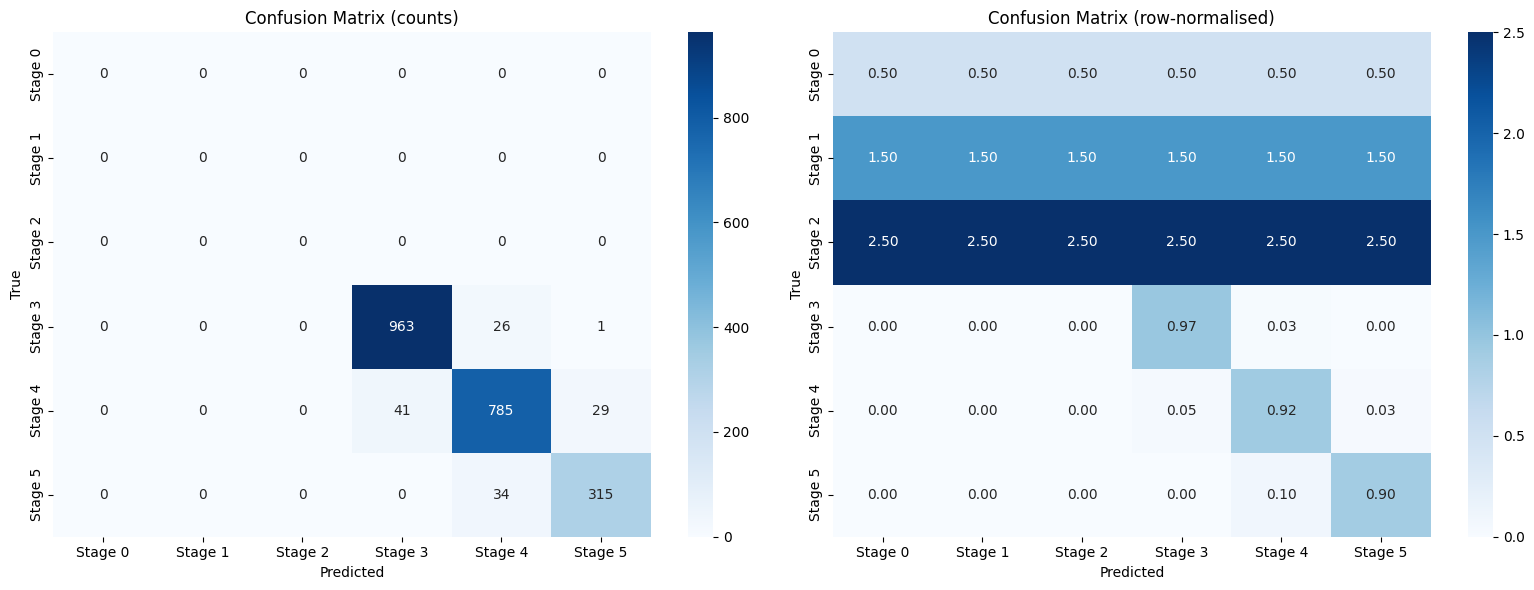

✓ Confusion matrix saved


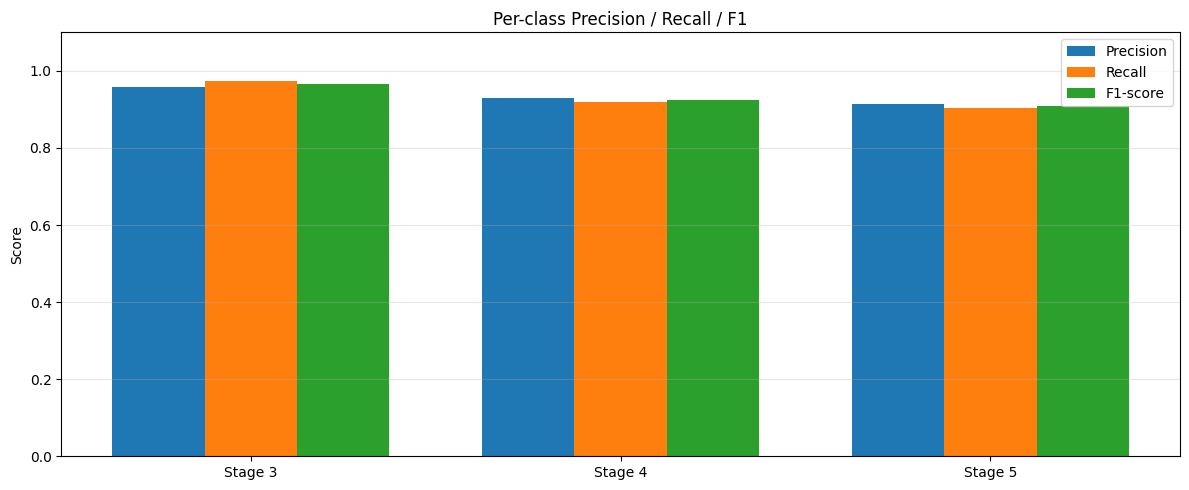

✓ Per-class metrics bar chart saved


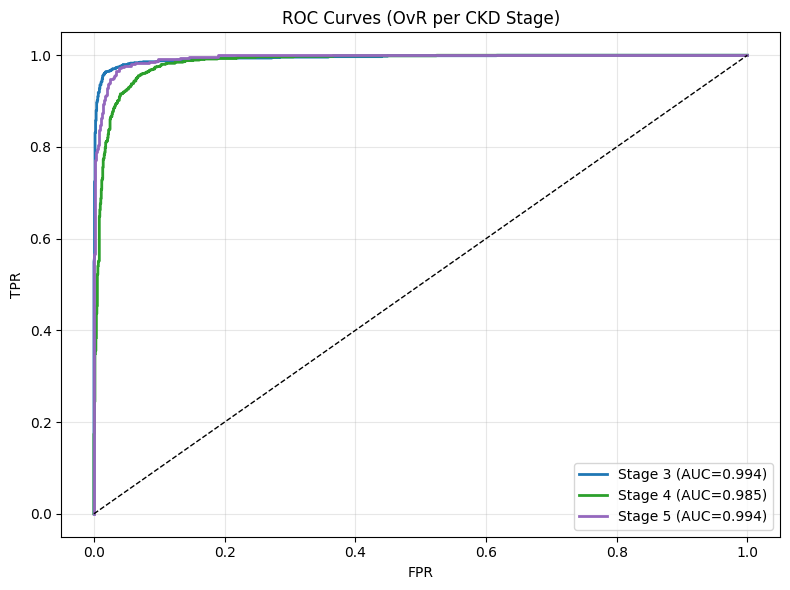

✓ ROC curves saved


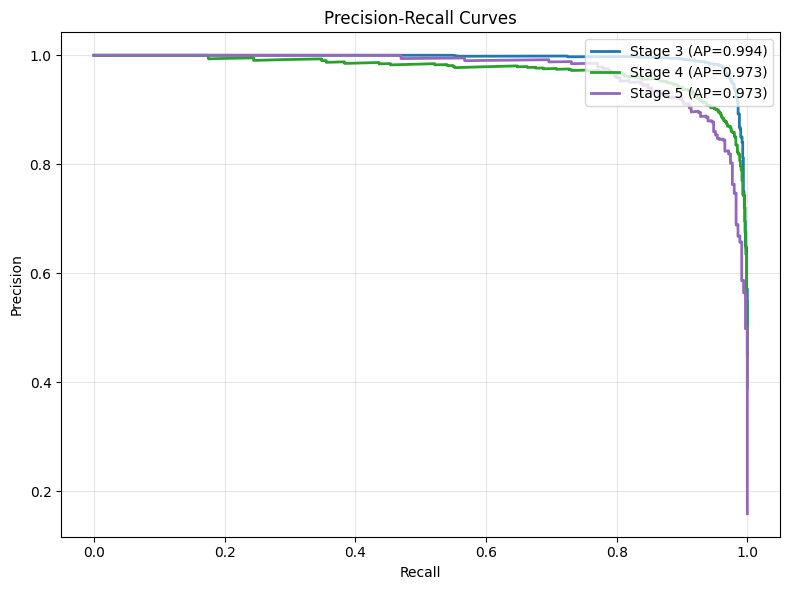

✓ PR curves saved


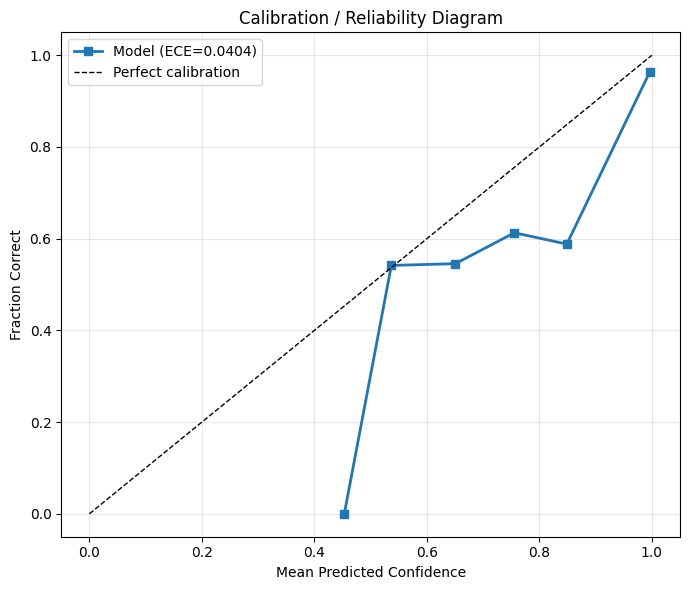

✓ Calibration diagram saved


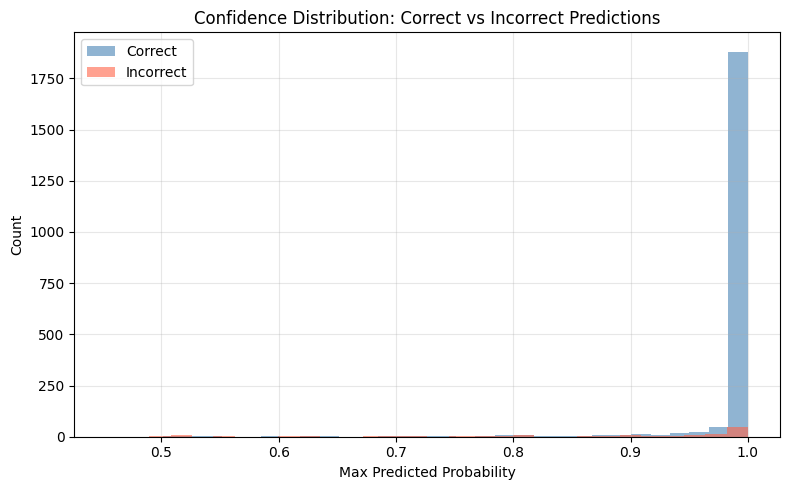

✓ Confidence distribution saved

              COMPREHENSIVE TEST METRICS               
  Accuracy                       0.9403
  Loss (Cross-Entropy)           0.2377
  Macro Precision                0.9337
  Macro Recall                   0.9311
  Macro F1                       0.9324
  Weighted F1                    0.9401
  AUC-ROC (macro OvR)            0.9910
  PR-AUC (macro)                 0.9800
  ECE                            0.0404
  Brier Score                    0.0166


In [14]:
import itertools
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from pathlib import Path
import json

# Define OUTPUT_DIR locally for this cell to ensure it's always available
OUTPUT_DIR = Path('/content/drive/MyDrive/ckd_model/outputs')

# Ensure the output directory exists
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Check if history is defined, otherwise load it from file
if 'history' not in locals() and 'history' not in globals():
    history_path = OUTPUT_DIR / 'history.json'
    if history_path.exists():
        with open(history_path, 'r') as f:
            history = json.load(f)
        print("✓ Loaded history from file.")
    else:
        raise NameError("history is not defined and 'history.json' not found. Please ensure cell XV9lmKtMk_42 is run before this cell, or that history.json exists.")

t_targets  = np.array(history['test_targets'])
t_preds    = np.array(history['test_preds'])
probs      = np.array(history['test_probs'])
n_classes  = probs.shape[1]
present    = np.unique(t_targets)
stage_labels = [f"Stage {i}" for i in range(n_classes)]

# ══════════════════════════════════════════════════════════════════════════════
# 1. Confusion Matrix
# ══════════════════════════════════════════════════════════════════════════════
cm = np.array(history['test_cm'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=stage_labels, yticklabels=stage_labels, ax=axes[0])
axes[0].set(title='Confusion Matrix (counts)',
            xlabel='Predicted', ylabel='True')

# Row-normalised (recall per class)
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm_norm, row_sums, where=row_sums!=0)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=stage_labels, yticklabels=stage_labels, ax=axes[1])
axes[1].set(title='Confusion Matrix (row-normalised)',
            xlabel='Predicted', ylabel='True')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved")

# ══════════════════════════════════════════════════════════════════════════════
# 2. Per-class Metrics Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
per_class = history['test_per_class']
class_keys = [str(c) for c in present]

metrics_names = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(metrics_names):
    vals = [per_class.get(k, {}).get(m, 0) for k in class_keys]
    ax.bar(x + i*width, vals, width, label=m.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels([f"Stage {k}" for k in class_keys])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-class Precision / Recall / F1')
ax.legend(); ax.grid(True, alpha=.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Per-class metrics bar chart saved")

# ══════════════════════════════════════════════════════════════════════════════
# 3. ROC Curves (OvR per class)
# ══════════════════════════════════════════════════════════════════════════════

t_bin = label_binarize(t_targets, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for c, col in zip(present, colors):
    if t_bin[:, c].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(t_bin[:, c], probs[:, c])
    auc_c = roc_auc_score(t_bin[:, c], probs[:, c])
    ax.plot(fpr, tpr, color=col, lw=2, label=f"Stage {c} (AUC={auc_c:.3f})")

ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC Curves (OvR per CKD Stage)')
ax.legend(loc='lower right'); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ ROC curves saved")

# ══════════════════════════════════════════════════════════════════════════════
# 4. Precision-Recall Curves
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
for c, col in zip(present, colors):
    if t_bin[:, c].sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(t_bin[:, c], probs[:, c])
    ap = average_precision_score(t_bin[:, c], probs[:, c])
    ax.plot(rec, prec, color=col, lw=2, label=f"Stage {c} (AP={ap:.3f})")

ax.set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
ax.legend(loc='upper right'); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ PR curves saved")

# ══════════════════════════════════════════════════════════════════════════════
# 5. Calibration (Reliability) Diagram
# ══════════════════════════════════════════════════════════════════════════════
confidence = probs.max(axis=1)
correct     = (t_preds == t_targets).astype(float)

fig, ax = plt.subplots(figsize=(7, 6))
frac_pos, mean_pred = calibration_curve(correct, confidence, n_bins=10, strategy='uniform')
ax.plot(mean_pred, frac_pos, 's-', label=f"Model (ECE={history['test_ece']:.4f})", lw=2)
ax.plot([0,1],[0,1], 'k--', label='Perfect calibration', lw=1)
ax.set(xlabel='Mean Predicted Confidence', ylabel='Fraction Correct',
       title='Calibration / Reliability Diagram')
ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Calibration diagram saved")

# ══════════════════════════════════════════════════════════════════════════════
# 6. Prediction Confidence Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(confidence[correct==1], bins=30, alpha=.6, label='Correct',   color='steelblue')
ax.hist(confidence[correct==0], bins=30, alpha=.6, label='Incorrect', color='tomato')
ax.set(xlabel='Max Predicted Probability', ylabel='Count',
       title='Confidence Distribution: Correct vs Incorrect Predictions')
ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confidence distribution saved")

# ══════════════════════════════════════════════════════════════════════════════
# 7. Summary Metrics Table
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print(f"{'COMPREHENSIVE TEST METRICS':^55}")
print("="*55)
rows = [
    ("Accuracy",            f"{history['test_acc']:.4f}"),
    ("Loss (Cross-Entropy)", f"{history['test_loss']:.4f}"),
    ("Macro Precision",     f"{history['test_precision']:.4f}"),
    ("Macro Recall",        f"{history['test_recall']:.4f}"),
    ("Macro F1",            f"{history['test_macro_f1']:.4f}"),
    ("Weighted F1",         f"{history['test_weighted_f1']:.4f}"),
    ("AUC-ROC (macro OvR)", f"{history['test_auc_roc']:.4f}" if not np.isnan(history['test_auc_roc']) else "N/A"),
    ("PR-AUC (macro)",      f"{history['test_pr_auc']:.4f}"  if not np.isnan(history['test_pr_auc'])  else "N/A"),
    ("ECE",                 f"{history['test_ece']:.4f}"),
    ("Brier Score",         f"{history['test_brier']:.4f}"),
]
for name, val in rows:
    print(f"  {name:<26} {val:>10}")
print("="*55)


### Download `history.json` from Google Drive

Since the `history.json` file was not found, I will download it from the Google Drive link you provided to ensure it's available for plotting. This step involves installing a utility and then downloading the file.

In [15]:
# Install gdown if not already installed
import subprocess
import sys

print("Installing gdown...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
print("✓ gdown installed")

Installing gdown...
✓ gdown installed


In [16]:
import gdown
from pathlib import Path

# Define OUTPUT_DIR locally for this cell to ensure it's always available
OUTPUT_DIR = Path('/content/drive/MyDrive/ckd_model/outputs')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True) # Ensure output dir exists

# Google Drive file ID extracted from the share link
# For 'https://drive.google.com/file/d/1XGf5SFcQeBwxqaMP-BnYzgINcJfuzPiU/view?usp=drive_link'
file_id = '1XGf5SFcQeBwxqaMP-BnYzgINcJfuzPiU'
destination_path = OUTPUT_DIR / 'history.json'

print(f"Downloading history.json from Google Drive to {destination_path}...")
try:
    gdown.download(id=file_id, output=str(destination_path), quiet=False, fuzzy=True)
    print(f"✓ history.json downloaded successfully to {destination_path}")
except Exception as e:
    print(f"Error downloading file: {e}")
    print("Please ensure the Google Drive link is accessible and you have permission.")

Downloading...
From: https://drive.google.com/uc?id=1XGf5SFcQeBwxqaMP-BnYzgINcJfuzPiU
To: /content/drive/MyDrive/ckd_model/outputs/history.json
100%|██████████| 8.42k/8.42k [00:00<00:00, 24.6MB/s]

✓ history.json downloaded successfully to /content/drive/MyDrive/ckd_model/outputs/history.json


After executing the above cells, please re-run cell `TcFYH6v75q-I` to generate the plots using the downloaded `history.json` file.

In [17]:
import torch

# Save model
torch.save(model.state_dict(), f'{OUTPUT_DIR}/model.pt')
print(f"✓ Model saved to {OUTPUT_DIR}/model.pt")

# Save history (serialise numpy/lists)
def _serialise(obj):
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, dict): return {k: _serialise(v) for k, v in obj.items()}
    if isinstance(obj, list): return [_serialise(x) for x in obj]
    return obj

history_save = _serialise({k: v for k, v in history.items()
                            if k not in ('test_probs', 'test_targets', 'test_preds')})
with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history_save, f, indent=2)
print("✓ History saved")

# Summary
print(f"\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(f"Test Accuracy           : {history['test_acc']:.4f}")
print(f"Test Loss               : {history['test_loss']:.4f}")
print(f"Test Macro F1           : {history['test_macro_f1']:.4f}")
print(f"Test Weighted F1        : {history['test_weighted_f1']:.4f}")
print(f"Test Macro Precision    : {history['test_precision']:.4f}")
print(f"Test Macro Recall       : {history['test_recall']:.4f}")
print(f"Test AUC-ROC (macro)    : {history['test_auc_roc']:.4f}" if not isinstance(history['test_auc_roc'], float) or not np.isnan(history['test_auc_roc']) else "Test AUC-ROC            : N/A")
print(f"Test PR-AUC (macro)     : {history['test_pr_auc']:.4f}"  if not isinstance(history['test_pr_auc'], float)  or not np.isnan(history['test_pr_auc'])  else "Test PR-AUC             : N/A")
print(f"Test ECE                : {history['test_ece']:.4f}")
print(f"Test Brier Score        : {history['test_brier']:.4f}")
print(f"Best Val F1             : {max(history['val_f1']):.4f}")
print(f"\nAll files saved to: {OUTPUT_DIR}")
print("="*80)


✓ Model saved to /content/drive/MyDrive/ckd_model/outputs/model.pt
✓ History saved

FINAL RESULTS
Test Accuracy           : 0.9403
Test Loss               : 0.2377
Test Macro F1           : 0.9324
Test Weighted F1        : 0.9401
Test Macro Precision    : 0.9337
Test Macro Recall       : 0.9311
Test AUC-ROC (macro)    : 0.9910
Test PR-AUC (macro)     : 0.9800
Test ECE                : 0.0404
Test Brier Score        : 0.0166
Best Val F1             : 0.9378

All files saved to: /content/drive/MyDrive/ckd_model/outputs


In [ ]:
from google.colab import files

print("\nDownload results from Google Drive or use the commands below:")
print(f"\nFiles saved to: {OUTPUT_DIR}")
print(f"  • training_curves.png")
print(f"  • confusion_matrix.png")
print(f"  • per_class_metrics.png")
print(f"  • roc_curves.png")
print(f"  • pr_curves.png")
print(f"  • calibration.png")
print(f"  • confidence_distribution.png")
print(f"  • model.pt")
print(f"  • history.json")
print(f"  • feature_stats.json")

import shutil
shutil.make_archive(f'{OUTPUT_DIR}/ckd_results', 'zip', OUTPUT_DIR)
print(f"\n✓ Created: {OUTPUT_DIR}/ckd_results.zip")
print("Available for download from Google Drive")



Download results from Google Drive or use the commands below:

Files saved to: /content/drive/MyDrive/ckd_model/outputs
  • training_curves.png
  • confusion_matrix.png
  • per_class_metrics.png
  • roc_curves.png
  • pr_curves.png
  • calibration.png
  • confidence_distribution.png
  • model.pt
  • history.json
  • feature_stats.json
